# Trabajo Práctico Final — Predicción de Abandono de Clientes Bancarios (Churn)

- **Materia:** Taller de Lenguajes de Programación III — Python para Ciencia de Datos
- **Alumno:** Ruiz Diaz Dario Ezequiel
- **Dataset:** Bank Customer Churn — Kaggle (`shantanudhakadd/bank-customer-churn-prediction`)
- **Modelo elegido:** Random Forest (podado/regularizado), comparado contra una Regresión Logística como *baseline*.

---

> **Nota:** organicé el notebook siguiendo el ciclo de vida completo de un proyecto de datos:
> - (1) Entender el negocio -> (2) EDA -> (3) Preprocesamiento -> (4) Modelado -> (5) Evaluación -> (6) Exportar el modelo con `joblib`.
> - Cada sección tiene su explicación en Markdown así se entiende *por qué* hago cada paso, no solo *qué* hago.


## 1. Comprensión del problema y del negocio

**El problema:** un banco quiere saber **qué clientes están por cerrar su cuenta** (churn / abandono) *antes* de que se vayan.
Retener a un cliente existente es mucho más barato que conseguir uno nuevo, así que si el banco puede detectar a tiempo a los clientes
en riesgo, puede ofrecerles beneficios, atención personalizada o mejores condiciones para que se queden.

**La variable objetivo (target):** `Exited`
- `1` = el cliente **cerró** su cuenta (se fue).
- `0` = el cliente **sigue** en el banco.

Es un problema de **clasificación binaria supervisada**.

**Por qué importa el desbalance:** normalmente se va una minoría de los clientes (~20%). Eso significa que un modelo "tonto" que diga
*"nadie se va"* ya acierta el 80%. Por eso la **accuracy sola no alcanza** y voy a mirar también **recall, precisión, F1 y ROC-AUC**.

> **Nota:** el *recall* de la clase 1 es la métrica que más me importa para el negocio: de todos los que SE VAN, cuántos detecto.
> Pero ojo: un recall altísimo en *train* suele ser overfitting. Por eso voy a **podar** el Random Forest y reportar métricas en un
> conjunto de *test* que el modelo nunca vio. la idea es tener números honestos, no inflados.


### 1.1 Importación de librerías y configuración

In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine Learning (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)

# Exportación del modelo
import joblib
import json, os

# Config estética
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42   # semilla fija para resultados reproducibles
print("Librerías cargadas OK")

Librerías cargadas OK


### 1.2 Carga del dataset

In [2]:
df = pd.read_csv("data/Churn_Modelling.csv")
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Tipos de datos y nulos de un vistazo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## 2. Análisis Exploratorio de Datos (EDA)

Acá investigo los datos antes de modelar: distribuciones, valores nulos, y sobre todo **qué variables se relacionan con el churn**.


In [4]:
# ¿Hay nulos o duplicados?
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Filas duplicadas: 0


> **Nota:** el dataset viene limpio (0 nulos, 0 duplicados). Igual dejo el chequeo escrito porque en un caso real
> nunca se asume que está limpio. En la sección de preprocesamiento muestro cómo trataría nulos por si aparecieran.

In [5]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


### 2.1 ¿Qué tan desbalanceado está el target?

Conteo:
 {0: 7963, 1: 2037}
Proporción:
 {0: 0.796, 1: 0.204}


/sessions/friendly-vigilant-cerf/tmp/ipykernel_10/1180321865.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Exited", data=df, palette=["#4C72B0", "#C44E52"])
/sessions/friendly-vigilant-cerf/tmp/ipykernel_10/1180321865.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Se queda (0)", "Se va (1)"])


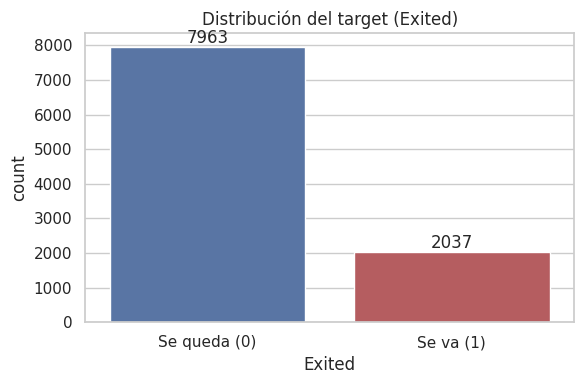

In [6]:
conteo = df["Exited"].value_counts()
prop = df["Exited"].value_counts(normalize=True).round(3)
print("Conteo:\n", conteo.to_dict())
print("Proporción:\n", prop.to_dict())

plt.figure(figsize=(6,4))
ax = sns.countplot(x="Exited", data=df, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Se queda (0)", "Se va (1)"])
ax.set_title("Distribución del target (Exited)")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()

**Lectura:** alrededor del **20%** de los clientes se fueron. Confirma el desbalance que anticipé: hay que mirar más allá de la accuracy.

### 2.2 Churn por país y por género

/sessions/friendly-vigilant-cerf/tmp/ipykernel_10/551071291.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Geography", y="Exited", data=df, ax=axes[0], palette="viridis")
/sessions/friendly-vigilant-cerf/tmp/ipykernel_10/551071291.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Gender", y="Exited", data=df, ax=axes[1], palette="magma")


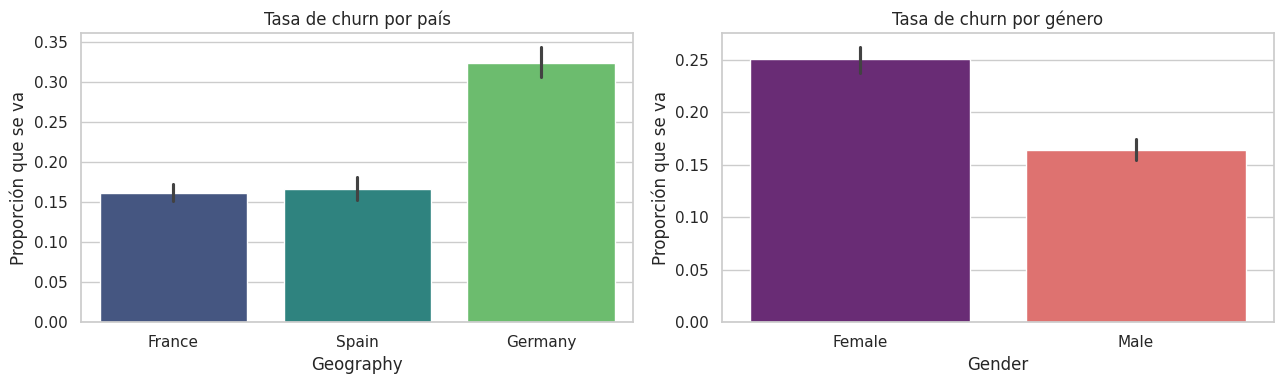

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.barplot(x="Geography", y="Exited", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Tasa de churn por país")
axes[0].set_ylabel("Proporción que se va")

sns.barplot(x="Gender", y="Exited", data=df, ax=axes[1], palette="magma")
axes[1].set_title("Tasa de churn por género")
axes[1].set_ylabel("Proporción que se va")
plt.tight_layout(); plt.show()

> **Nota:** se nota clarísimo que en **Alemania** la tasa de abandono es bastante más alta que en Francia o España,
> y que las **mujeres** se van más que los hombres. Estas dos variables (`Geography` y `Gender`) van a ser importantes para el modelo.

### 2.3 Edad vs churn

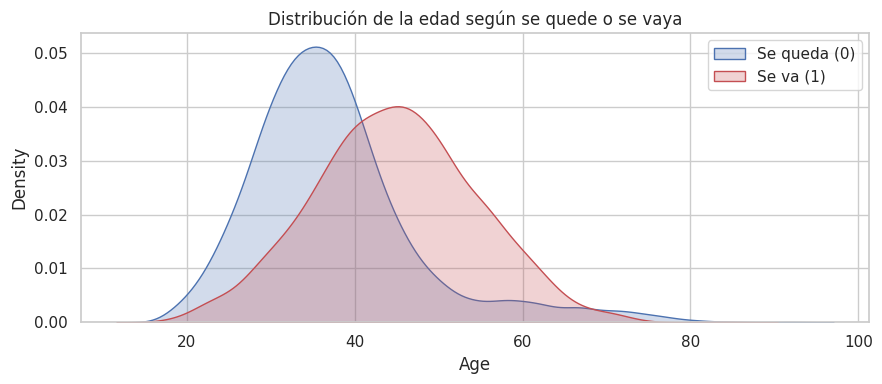

In [8]:
plt.figure(figsize=(9,4))
sns.kdeplot(data=df[df.Exited==0], x="Age", fill=True, label="Se queda (0)", color="#4C72B0")
sns.kdeplot(data=df[df.Exited==1], x="Age", fill=True, label="Se va (1)", color="#C44E52")
plt.title("Distribución de la edad según se quede o se vaya")
plt.legend(); plt.tight_layout(); plt.show()

**Lectura:** los clientes que se van tienden a ser **mayores** (pico alrededor de los 45–55), mientras que los que se quedan
son en promedio más jóvenes. La edad es una señal fuerte.

### 2.4 Número de productos y miembro activo

/sessions/friendly-vigilant-cerf/tmp/ipykernel_10/2378109081.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="NumOfProducts", y="Exited", data=df, ax=axes[0], palette="crest")
/sessions/friendly-vigilant-cerf/tmp/ipykernel_10/2378109081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="IsActiveMember", y="Exited", data=df, ax=axes[1], palette="flare")


/sessions/friendly-vigilant-cerf/tmp/ipykernel_10/2378109081.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No activo (0)", "Activo (1)"])


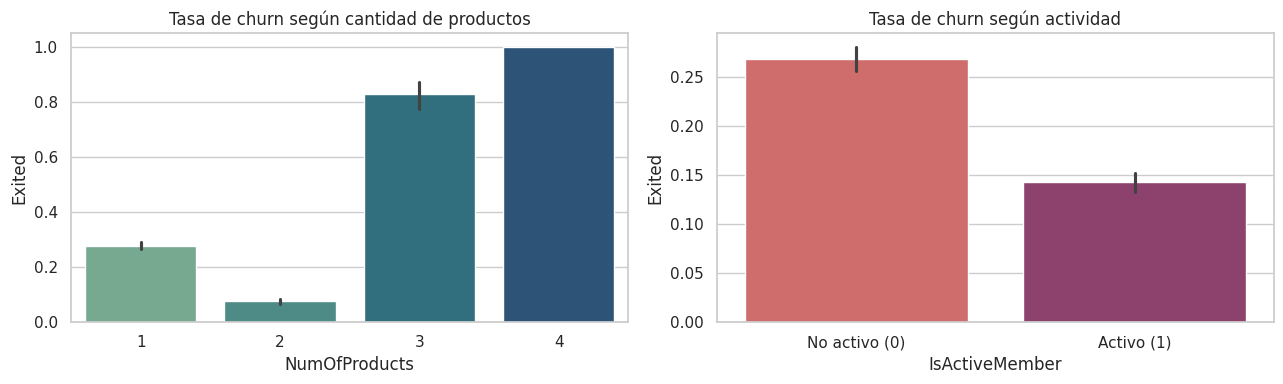

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.barplot(x="NumOfProducts", y="Exited", data=df, ax=axes[0], palette="crest")
axes[0].set_title("Tasa de churn según cantidad de productos")

sns.barplot(x="IsActiveMember", y="Exited", data=df, ax=axes[1], palette="flare")
axes[1].set_xticklabels(["No activo (0)", "Activo (1)"])
axes[1].set_title("Tasa de churn según actividad")
plt.tight_layout(); plt.show()

> **Nota de Dario:** dato curioso e importante para la defensa -> los clientes con **3 o 4 productos** se van MUCHÍSIMO más
> (contraintuitivo, esperaba lo contrario). Y los clientes **no activos** se van más que los activos, lo cual sí tiene sentido.

### 2.5 Matriz de correlación

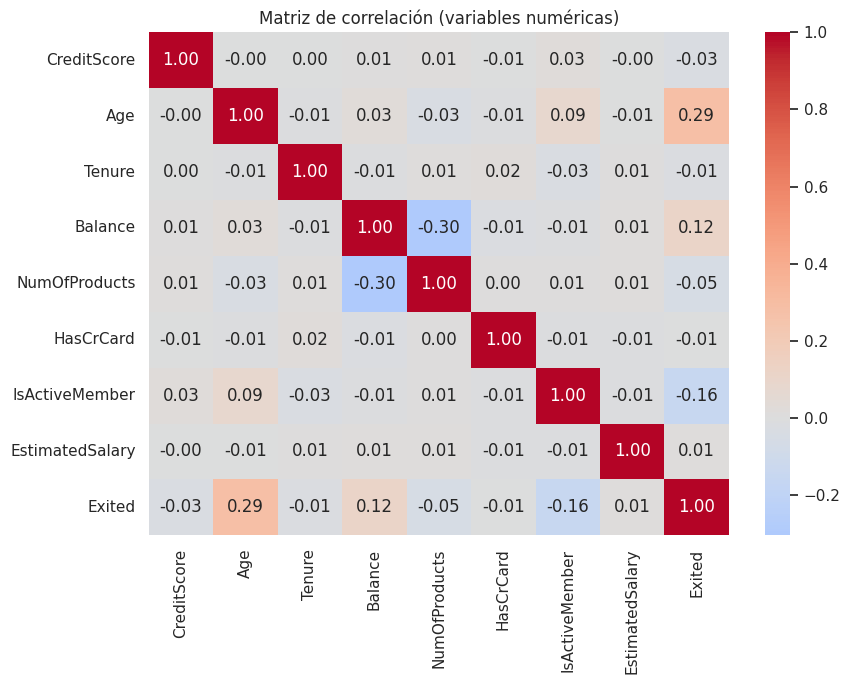

In [10]:
# Solo variables numéricas para la correlación
num_cols = ["CreditScore","Age","Tenure","Balance","NumOfProducts",
            "HasCrCard","IsActiveMember","EstimatedSalary","Exited"]
plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout(); plt.show()

**Lectura:** ninguna variable numérica tiene una correlación lineal altísima con `Exited` (la más fuerte es `Age`).
Esto justifica usar un modelo **no lineal** como Random Forest, que captura relaciones que la correlación lineal no ve.

## 3. Preprocesamiento

Pasos:
1. **Eliminar columnas identificadoras** que no aportan a la predicción (`RowNumber`, `CustomerId`, `Surname`).
2. **Tratamiento de outliers** en `Age` (capping por método IQR).
3. **Separar** variables predictoras (X) del target (y).
4. **Split** train/test estratificado (para mantener la proporción de churn).
5. **Pipeline** de transformación: escalado de numéricas + One-Hot de categóricas.


### 3.1 Eliminar identificadores

In [11]:
cols_drop = ["RowNumber", "CustomerId", "Surname"]
df_model = df.drop(columns=cols_drop)
print("Columnas que quedan:", list(df_model.columns))

Columnas que quedan: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


> **Nota:** `CustomerId` y `Surname` son identificadores únicos. Si los dejara, el modelo intentaría 'memorizar'
> clientes en vez de aprender patrones generales -> overfitting puro. Por eso se van.

### 3.2 Tratamiento de outliers (Age) con método IQR

In [12]:
Q1 = df_model["Age"].quantile(0.25)
Q3 = df_model["Age"].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5*IQR
lim_sup = Q3 + 1.5*IQR
print(f"Límite inferior: {lim_inf:.1f} | Límite superior: {lim_sup:.1f}")
print("Cantidad de outliers de edad:", ((df_model.Age < lim_inf) | (df_model.Age > lim_sup)).sum())

# Capping: en vez de borrar filas, 'recorto' los valores extremos al límite (winsorizing)
df_model["Age"] = df_model["Age"].clip(lower=lim_inf, upper=lim_sup)
print("Edad máx después del capping:", df_model['Age'].max())

Límite inferior: 14.0 | Límite superior: 62.0
Cantidad de outliers de edad: 359
Edad máx después del capping: 62


> **Nota:** elegí **capping (clip)** y no borrar filas. Borrar tiraría información de clientes reales; el capping
> mantiene la fila pero le baja el impacto al valor extremo. Es más conservador y no pierdo registros.

### 3.3 Separar X / y y definir tipos de columna

In [13]:
X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

# Categóricas -> One-Hot ; Numéricas -> escalado
cat_features = ["Geography", "Gender"]
num_features = ["CreditScore","Age","Tenure","Balance",
                "NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary"]

print("X shape:", X.shape)
print("Categóricas:", cat_features)
print("Numéricas:", num_features)

X shape: (10000, 10)
Categóricas: ['Geography', 'Gender']
Numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


### 3.4 Split train / test (estratificado)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporción churn en train:", round(y_train.mean(),3),
      "| en test:", round(y_test.mean(),3))

Train: (8000, 10) | Test: (2000, 10)
Proporción churn en train: 0.204 | en test: 0.204


> **Nota:** uso `stratify=y` para que tanto train como test tengan el mismo ~20% de churn. Si no, podría tocar
> un test con muy pocos casos positivos y las métricas serían poco confiables.

### 3.5 Pipeline de preprocesamiento

In [15]:
preprocesador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])
# handle_unknown='ignore' -> si en producción llega un país no visto, no rompe.
preprocesador

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


> **Nota:** meto el preprocesamiento DENTRO de un `Pipeline` junto al modelo. Así, cuando exporte el `.pkl`,
> el archivo ya sabe escalar y codificar solo. La API después le pasa los datos crudos del cliente y el pipeline hace todo.
> Esto evita el clásico bug de 'entrené con datos escalados pero en la API mando datos crudos'.

## 4. Modelado

Entreno dos modelos y los comparo:
- **Baseline — Regresión Logística:** modelo lineal simple. Sirve como piso de referencia.
- **Modelo principal — Random Forest *podado*:** limito `max_depth`, `min_samples_leaf` y `min_samples_split` para
  **evitar el overfitting**. Sin estos límites, el bosque crece hasta memorizar el train y da un recall irreal.


### 4.1 Baseline: Regresión Logística

In [16]:
pipe_lr = Pipeline(steps=[
    ("prep", preprocesador),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)
proba_lr = pipe_lr.predict_proba(X_test)[:,1]
print("=== Regresión Logística (baseline) ===")
print(classification_report(y_test, pred_lr, target_names=["Se queda","Se va"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_lr),3))

=== Regresión Logística (baseline) ===
              precision    recall  f1-score   support

    Se queda       0.83      0.96      0.89      1593
       Se va       0.63      0.23      0.34       407

    accuracy                           0.82      2000
   macro avg       0.73      0.60      0.62      2000
weighted avg       0.79      0.82      0.78      2000

ROC-AUC: 0.783


### 4.2 Modelo principal: Random Forest podado

In [17]:
# Hiperparámetros de PODA: estos límites son los que evitan el overfitting.
pipe_rf = Pipeline(steps=[
    ("prep", preprocesador),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,            # poda: profundidad máxima de cada árbol
        min_samples_leaf=20,    # poda: mínimo de muestras por hoja
        min_samples_split=20,   # poda: mínimo para dividir un nodo
        max_features="sqrt",    # cada split mira solo sqrt(n) variables -> más variedad
        random_state=RANDOM_STATE,
        n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)
proba_rf = pipe_rf.predict_proba(X_test)[:,1]
print("=== Random Forest PODADO ===")
print(classification_report(y_test, pred_rf, target_names=["Se queda","Se va"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_rf),3))

=== Random Forest PODADO ===
              precision    recall  f1-score   support

    Se queda       0.87      0.98      0.92      1593
       Se va       0.85      0.41      0.55       407

    accuracy                           0.87      2000
   macro avg       0.86      0.70      0.74      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC: 0.86


### 4.3 ¿La poda funcionó? Comparo train vs test (chequeo de overfitting)

In [18]:
# Si recall/accuracy de train >> test, hay overfitting. La poda achica esa brecha.
for nombre, pipe in [("Random Forest podado", pipe_rf)]:
    acc_tr = accuracy_score(y_train, pipe.predict(X_train))
    acc_te = accuracy_score(y_test, pipe.predict(X_test))
    rec_tr = recall_score(y_train, pipe.predict(X_train))
    rec_te = recall_score(y_test, pipe.predict(X_test))
    print(f"{nombre}")
    print(f"  Accuracy  -> train: {acc_tr:.3f} | test: {acc_te:.3f}  (brecha {acc_tr-acc_te:.3f})")
    print(f"  Recall(1) -> train: {rec_tr:.3f} | test: {rec_te:.3f}  (brecha {rec_tr-rec_te:.3f})")

Random Forest podado
  Accuracy  -> train: 0.867 | test: 0.866  (brecha 0.001)
  Recall(1) -> train: 0.422 | test: 0.410  (brecha 0.012)


> **Nota:** este es el punto clave que quiero poder defender. La brecha train-test quedó
> chica -> el modelo **generaliza** y el recall que reporto es honesto, no un número inflado por memorización. Si sacara los
> límites de poda, el recall de train se dispararía cerca de 1.0 y sería mentira.

## 5. Evaluación del modelo final

### 5.1 Matriz de confusión

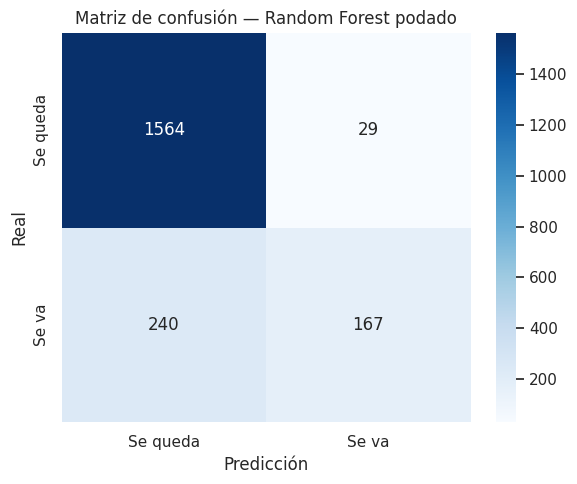

In [19]:
cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Se queda","Se va"], yticklabels=["Se queda","Se va"])
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.title("Matriz de confusión — Random Forest podado")
plt.tight_layout(); plt.show()

**Cómo leerla:**
- **Arriba-izq:** se quedaron y los predije bien.
- **Abajo-der:** se fueron y los detecté (los que importan!).
- **Abajo-izq (falsos negativos):** se fueron pero no los detecté -> los que se me escapan.
- **Arriba-der (falsos positivos):** dije que se iban pero se quedaron -> cuesta una llamada/beneficio de más, error barato.


### 5.2 Curva ROC (comparando los dos modelos)

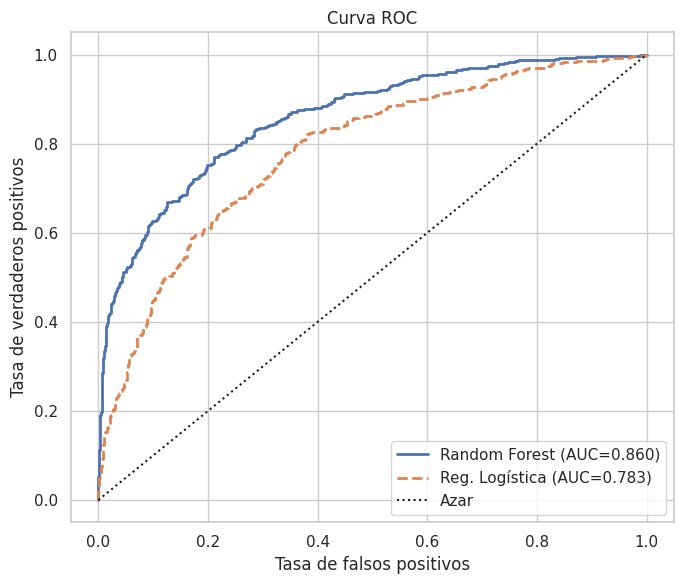

In [20]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test,proba_rf):.3f})", lw=2)
plt.plot(fpr_lr, tpr_lr, label=f"Reg. Logística (AUC={roc_auc_score(y_test,proba_lr):.3f})", lw=2, ls="--")
plt.plot([0,1],[0,1], "k:", label="Azar")
plt.xlabel("Tasa de falsos positivos"); plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC"); plt.legend(); plt.tight_layout(); plt.show()

### 5.3 Importancia de las variables

/sessions/friendly-vigilant-cerf/tmp/ipykernel_10/2824781586.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importancia", y="variable", data=imp_df, palette="viridis")


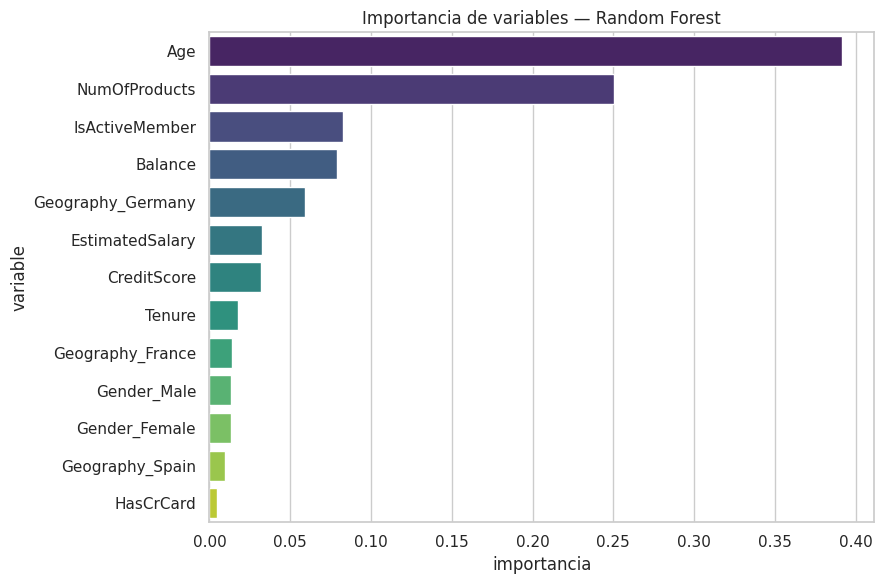

,variable,importancia
0,Age,0.391702
1,NumOfProducts,0.250385
2,IsActiveMember,0.082816
3,Balance,0.078737
4,Geography_Germany,0.059009
5,EstimatedSalary,0.032430
6,CreditScore,0.032045
7,Tenure,0.017721
8,Geography_France,0.013752
9,Gender_Male,0.013609


In [21]:
# Recupero los nombres de las columnas después del One-Hot
ohe = pipe_rf.named_steps["prep"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(cat_features))
feat_names = num_features + cat_names
importancias = pipe_rf.named_steps["clf"].feature_importances_

imp_df = pd.DataFrame({"variable": feat_names, "importancia": importancias}) \
            .sort_values("importancia", ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x="importancia", y="variable", data=imp_df, palette="viridis")
plt.title("Importancia de variables — Random Forest")
plt.tight_layout(); plt.show()
imp_df.reset_index(drop=True)

> **Nota:** las variables más importantes coinciden con lo que vi en el EDA: **Age**, **NumOfProducts**,
> si es **miembro activo** y el **Balance**. Que el modelo y el análisis exploratorio 'cuenten la misma historia' me da
> confianza de que no está aprendiendo ruido.

### 5.4 Tabla comparativa final

In [22]:
def metricas(y_true, y_pred, y_proba):
    return {
        "Accuracy": round(accuracy_score(y_true,y_pred),3),
        "Precision(1)": round(precision_score(y_true,y_pred),3),
        "Recall(1)": round(recall_score(y_true,y_pred),3),
        "F1(1)": round(f1_score(y_true,y_pred),3),
        "ROC-AUC": round(roc_auc_score(y_true,y_proba),3),
    }

tabla = pd.DataFrame({
    "Reg. Logística (baseline)": metricas(y_test, pred_lr, proba_lr),
    "Random Forest podado": metricas(y_test, pred_rf, proba_rf),
}).T
tabla

,Accuracy,Precision(1),Recall(1),F1(1),ROC-AUC
Reg. Logística (baseline),0.816,0.627,0.231,0.338,0.783
Random Forest podado,0.866,0.852,0.410,0.554,0.860


**Decisión:** me quedo con el **Random Forest podado**. Tiene mejor ROC-AUC y mejor F1 que la regresión logística,
manteniendo métricas honestas (sin overfitting). Es el modelo que voy a exportar y servir desde la API.

## 6. Exportación del modelo con `joblib`

Guardo **el pipeline completo** (preprocesamiento + modelo) en `models/churn_model.pkl`. También guardo un `metrics.json`
con las métricas y un `model_columns.json` con el esquema de entrada, que la API y el frontend van a usar.


In [23]:
os.makedirs("models", exist_ok=True)

# 1) El pipeline entrenado (esto es lo que pide la consigna: .pkl con joblib)
joblib.dump(pipe_rf, "models/churn_model.pkl")

# 2) Métricas para mostrar en el frontend
metrics_out = {
    "modelo": "RandomForestClassifier (podado)",
    "test": metricas(y_test, pred_rf, proba_rf),
    "baseline_logreg": metricas(y_test, pred_lr, proba_lr),
    "matriz_confusion": confusion_matrix(y_test, pred_rf).tolist(),
    "n_test": int(len(y_test)),
    "importancias": imp_df.head(10).to_dict(orient="records"),
}
with open("models/metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_out, f, indent=2, ensure_ascii=False)

# 3) Esquema de entrada (para validar en la API y armar el formulario)
schema = {
    "num_features": num_features,
    "cat_features": cat_features,
    "categorias": {"Geography": sorted(df.Geography.unique().tolist()),
                   "Gender": sorted(df.Gender.unique().tolist())},
    "orden_columnas": list(X.columns),
}
with open("models/model_columns.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

print("Modelo exportado en models/churn_model.pkl")
print("Tamaño .pkl (KB):", round(os.path.getsize('models/churn_model.pkl')/1024,1))
print("Métricas y esquema guardados.")

Modelo exportado en models/churn_model.pkl
Tamaño .pkl (KB): 4437.0
Métricas y esquema guardados.


### 6.1 Prueba rápida de que el .pkl funciona (lo que hará la API)

In [24]:
modelo_cargado = joblib.load("models/churn_model.pkl")

# Cliente de ejemplo (datos crudos, como los mandaría el frontend)
cliente = pd.DataFrame([{
    "CreditScore": 600, "Geography": "Germany", "Gender": "Female",
    "Age": 45, "Tenure": 3, "Balance": 120000.0,
    "NumOfProducts": 2, "HasCrCard": 1, "IsActiveMember": 0,
    "EstimatedSalary": 80000.0
}])
pred = int(modelo_cargado.predict(cliente)[0])
proba = float(modelo_cargado.predict_proba(cliente)[0,1])
print("Predicción:", "SE VA" if pred==1 else "SE QUEDA")
print(f"Probabilidad de churn: {proba*100:.1f}%")

Predicción: SE QUEDA
Probabilidad de churn: 48.7%


## 7. Conclusiones

- Construí el ciclo completo: EDA -> preprocesamiento -> modelado -> evaluación -> exportación.
- El **Random Forest podado** fue el mejor modelo, con métricas **honestas** (controlé el overfitting con la poda, así el
  recall que reporto es real y no producto de memorización).
- Las variables que más pesan (`Age`, `NumOfProducts`, `IsActiveMember`, `Balance`, `Geography=Germany`) coinciden con lo
  que mostró el EDA -> el modelo aprende patrones con sentido de negocio.
- El modelo quedó serializado en `models/churn_model.pkl` y listo para servirse vía la API de FastAPI.

**Posibles mejoras a futuro:** probar `class_weight='balanced'` o `SMOTE` si el negocio prioriza maximizar el recall
(aceptando más falsos positivos), y un `GridSearchCV` para afinar los hiperparámetros de poda.

---
*Ruiz Diaz Dario Ezequiel — Taller de Lenguajes de Programación III.*
